In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

In [96]:
df = pd.read_csv('loan_data_v3.csv')

In [97]:
df.head()

,Unnamed: 0,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,4847,26.0,male,Associate,43996.0,4,RENT,5000.0,VENTURE,10.37,0.11,4.0,675.0,No,0.0
1,13802,22.0,female,Bachelor,115708.0,0,MORTGAGE,20000.0,EDUCATION,7.88,0.17,3.0,635.0,No,0.0
2,39763,25.0,female,High School,57827.0,0,RENT,6000.0,PERSONAL,11.60,0.10,4.0,589.0,Yes,0.0
3,39215,31.0,female,Master,126727.0,9,RENT,24000.0,DEBTCONSOLIDATION,10.27,0.19,7.0,644.0,Yes,0.0
4,26369,33.0,female,Associate,120987.0,10,OWN,25000.0,MEDICAL,12.18,0.21,10.0,644.0,Yes,0.0


In [98]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [99]:
df.isnull().sum()

person_age                        488
person_gender                     294
person_education                  422
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                         336
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      522
previous_loan_defaults_on_file      0
loan_status                       250
dtype: int64

In [100]:
len(df)

8000

<Axes: xlabel='loan_status'>

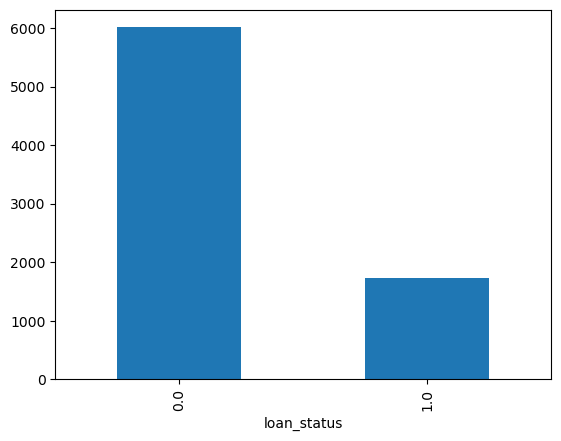

In [101]:
df['loan_status'].value_counts().plot.bar()

<Axes: >

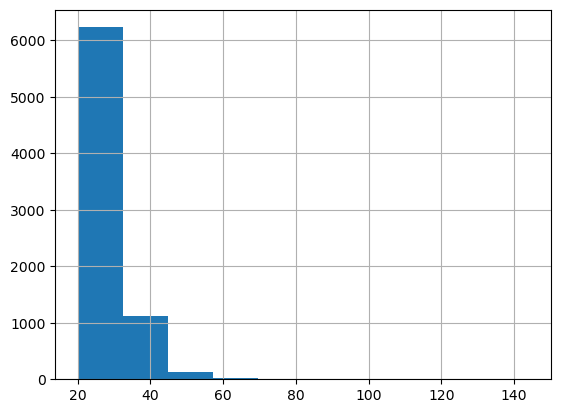

In [102]:
df['person_age'].hist()

In [103]:
df['person_age']=df['person_age'].fillna(df['person_age'].median())

In [104]:
df.isnull().sum()

person_age                          0
person_gender                     294
person_education                  422
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                         336
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      522
previous_loan_defaults_on_file      0
loan_status                       250
dtype: int64

In [105]:
df['person_gender']=df['person_gender'].map({"male":1,"female":0})

<Axes: xlabel='person_education'>

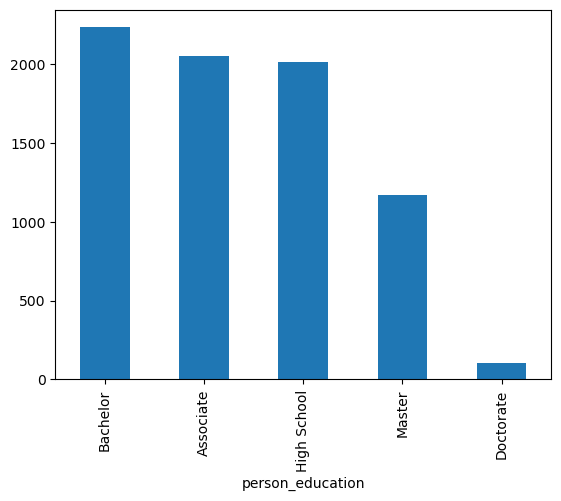

In [106]:
df['person_education'].value_counts().plot.bar()

In [107]:
education_order = ["High School", "Associate", "Bachelor", "Master", "Doctorate", np.nan]
ordinal_encoder=OrdinalEncoder(categories=[education_order])
df[['person_education']]=ordinal_encoder.fit_transform(df[['person_education']])

In [108]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,26.0,1.0,1.0,43996.0,4,RENT,5000.0,VENTURE,10.37,0.11,4.0,675.0,No,0.0
1,22.0,0.0,2.0,115708.0,0,MORTGAGE,20000.0,EDUCATION,7.88,0.17,3.0,635.0,No,0.0
2,25.0,0.0,0.0,57827.0,0,RENT,6000.0,PERSONAL,11.60,0.10,4.0,589.0,Yes,0.0
3,31.0,0.0,3.0,126727.0,9,RENT,24000.0,DEBTCONSOLIDATION,10.27,0.19,7.0,644.0,Yes,0.0
4,33.0,0.0,1.0,120987.0,10,OWN,25000.0,MEDICAL,12.18,0.21,10.0,644.0,Yes,0.0


<Axes: >

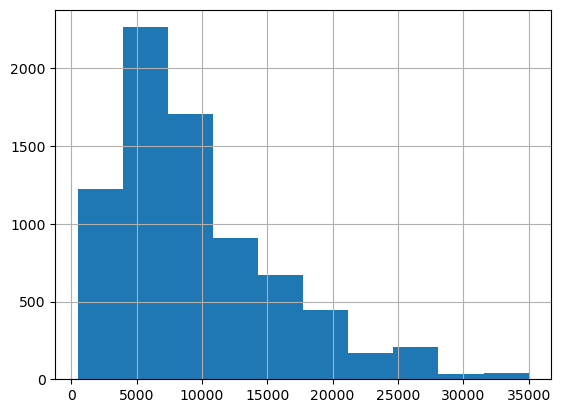

In [109]:
df['loan_amnt'].hist()

In [110]:
df['loan_amnt']=df['loan_amnt'].fillna(df['loan_amnt'].median())

In [111]:
df.isnull().sum()

person_age                          0
person_gender                     294
person_education                  422
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                           0
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      522
previous_loan_defaults_on_file      0
loan_status                       250
dtype: int64

<Axes: >

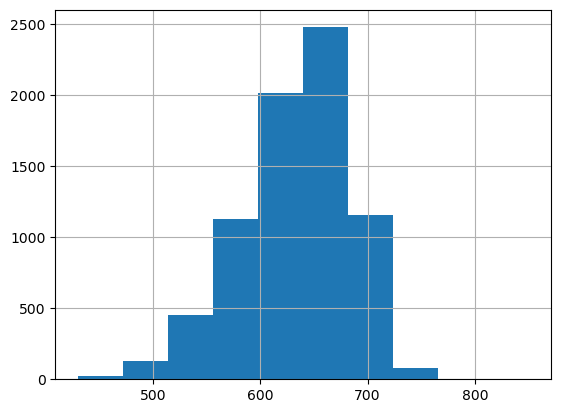

In [112]:
df['credit_score'].hist()

In [113]:
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].mean())

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      8000 non-null   float64
 1   person_gender                   7706 non-null   float64
 2   person_education                7578 non-null   float64
 3   person_income                   8000 non-null   float64
 4   person_emp_exp                  8000 non-null   int64  
 5   person_home_ownership           8000 non-null   object 
 6   loan_amnt                       8000 non-null   float64
 7   loan_intent                     8000 non-null   object 
 8   loan_int_rate                   8000 non-null   float64
 9   loan_percent_income             8000 non-null   float64
 10  cb_person_cred_hist_length      8000 non-null   float64
 11  credit_score                    8000 non-null   float64
 12  previous_loan_defaults_on_file  80

In [115]:
label_encoder=LabelEncoder()
df['person_home_ownership']=label_encoder.fit_transform(df['person_home_ownership'])

In [116]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,26.0,1.0,1.0,43996.0,4,3,5000.0,VENTURE,10.37,0.11,4.0,675.0,No,0.0
1,22.0,0.0,2.0,115708.0,0,0,20000.0,EDUCATION,7.88,0.17,3.0,635.0,No,0.0
2,25.0,0.0,0.0,57827.0,0,3,6000.0,PERSONAL,11.60,0.10,4.0,589.0,Yes,0.0
3,31.0,0.0,3.0,126727.0,9,3,24000.0,DEBTCONSOLIDATION,10.27,0.19,7.0,644.0,Yes,0.0
4,33.0,0.0,1.0,120987.0,10,2,25000.0,MEDICAL,12.18,0.21,10.0,644.0,Yes,0.0


In [117]:
loan_intents = pd.get_dummies(df['loan_intent'], prefix='loan_intent')
df = pd.concat([df, loan_intents], axis=1)
df.drop(columns=['loan_intent'], inplace=True)

In [118]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,26.0,1.0,1.0,43996.0,4,3,5000.0,10.37,0.11,4.0,675.0,No,0.0,False,False,False,False,False,True
1,22.0,0.0,2.0,115708.0,0,0,20000.0,7.88,0.17,3.0,635.0,No,0.0,False,True,False,False,False,False
2,25.0,0.0,0.0,57827.0,0,3,6000.0,11.60,0.10,4.0,589.0,Yes,0.0,False,False,False,False,True,False
3,31.0,0.0,3.0,126727.0,9,3,24000.0,10.27,0.19,7.0,644.0,Yes,0.0,True,False,False,False,False,False
4,33.0,0.0,1.0,120987.0,10,2,25000.0,12.18,0.21,10.0,644.0,Yes,0.0,False,False,False,True,False,False


In [119]:
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

<Axes: >

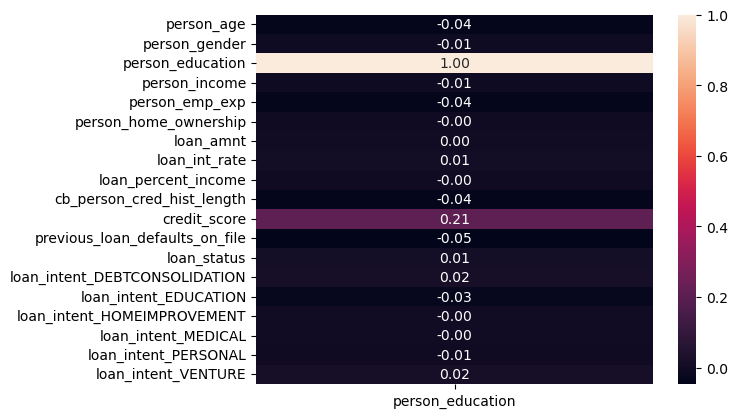

In [120]:
sns.heatmap(df.corr()[['person_education']],annot=True,fmt=".2f")

In [121]:
df.dropna(subset=['loan_status'],inplace=True)

In [123]:
df.isnull().sum()

person_age                          0
person_gender                     289
person_education                  409
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                           0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                        0
previous_loan_defaults_on_file      0
loan_status                         0
loan_intent_DEBTCONSOLIDATION       0
loan_intent_EDUCATION               0
loan_intent_HOMEIMPROVEMENT         0
loan_intent_MEDICAL                 0
loan_intent_PERSONAL                0
loan_intent_VENTURE                 0
dtype: int64

In [124]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

In [125]:
imputer = KNNImputer(n_neighbors=3)
imputed = imputer.fit_transform(scaled)

In [126]:
df=pd.DataFrame(scaler.inverse_transform(imputed),columns=df.columns)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7750 entries, 0 to 7749
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      7750 non-null   float64
 1   person_gender                   7750 non-null   float64
 2   person_education                7750 non-null   float64
 3   person_income                   7750 non-null   float64
 4   person_emp_exp                  7750 non-null   float64
 5   person_home_ownership           7750 non-null   float64
 6   loan_amnt                       7750 non-null   float64
 7   loan_int_rate                   7750 non-null   float64
 8   loan_percent_income             7750 non-null   float64
 9   cb_person_cred_hist_length      7750 non-null   float64
 10  credit_score                    7750 non-null   float64
 11  previous_loan_defaults_on_file  7750 non-null   float64
 12  loan_status                     77

In [128]:
df['person_gender']=df['person_gender'].astype(int)

In [129]:
df['person_education']=df['person_education'].astype(int)

In [130]:
X, y = df.drop(columns=["loan_status"]), df["loan_status"]

In [131]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [132]:
train_X=scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)

In [133]:
classifier = LogisticRegression().fit(train_X, train_y)

In [134]:
pred_y = classifier.predict(test_X)

In [136]:
print(classification_report(test_y,pred_y))

              precision    recall  f1-score   support

         0.0       0.92      0.93      0.92      1193
         1.0       0.75      0.71      0.73       357

    accuracy                           0.88      1550
   macro avg       0.83      0.82      0.83      1550
weighted avg       0.88      0.88      0.88      1550



In [137]:
classifier = DecisionTreeClassifier().fit(train_X, train_y)

In [141]:
param_grid = {
    "criterion": ["entropy", "gini"],
    "max_depth": [None, 1, 2, 3, 4],
}

In [142]:
grid_search=GridSearchCV(
    classifier,
    param_grid,
    scoring='f1_weighted',
    cv=5
)

In [144]:
grid_search.fit(train_X, train_y)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [None, 1, 2, 3, 4]},
             scoring='f1_weighted')

In [145]:
pred_y = grid_search.predict(test_X)

In [146]:
print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      1193
         1.0       0.85      0.74      0.79       357

    accuracy                           0.91      1550
   macro avg       0.89      0.85      0.87      1550
weighted avg       0.91      0.91      0.91      1550

